# 03 Modelling

## 1. Scoring harness and mean-prediction benchmark

The competition metric is hidden. `inrange.scoring` implements our own approximation of it, and every evaluation in this notebook reports the composite **and** each component, so no conclusion rests on our weights alone.

**Components** (mean over shots): landing position error and apex position error (Euclidean distance over x, y, z, in metres), apex time and landing time error (absolute, seconds), launch spin error (absolute, rpm).

**Scaling.** Each component is divided by the error of predicting the training mean for every shot, computed in-sample on all 491 training rows. A scaled component of 1.0 means "no better than the training mean".

**Weights.** landing position 0.40, apex position 0.25, apex time 0.125, landing time 0.125, spin 0.10. They sum to 1 and follow the stated priority order. They are a judgement call, not the real weights.

**Cross-validation.** Two strategies, always reported together:

* *Leave-one-session-out*: 11 folds, one per practice session from `01_eda.ipynb`. Whole sessions are held out, which is harder than the real test. Per-session scores show which sessions are hard.
* *Within-session*: 10 repeated random holdouts in which every session holds out the same share of its training rows as the real split put in test (38% to 62%). This mirrors how the real test set was drawn.

Each report also breaks errors down by ball speed band and gives a **test speed mix** composite: the band results reweighted to the share of test shots in each band, because test has far more shots above 70 m/s than train. That figure leans on only 37 fast training shots, so its spread is reported two ways: the standard deviation across folds or repeats that contain every band, and a bootstrap over shots within each band.

In [1]:
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from inrange.io import SUBMISSIONS_DIR, REPO_ROOT, TARGET_COLS, load_sample_submission, load_test, load_train, write_submission
from inrange.features import add_sessions, session_labels, speed_band
from inrange.models import SHOT_FRAME_TARGETS, LGBMBaseline, lgbm_fit_predict, shot_frame_targets, targets_from_shot_frame
from inrange.scoring import (
    COMPONENTS, REFERENCE_SCALES, WEIGHTS, compute_reference_scales, evaluate, report_table, score, test_mix_table,
)

warnings.filterwarnings("ignore", category=FutureWarning)
FIG_DIR = REPO_ROOT / "outputs" / "figures"

pd.set_option("display.width", 200, "display.max_columns", 30, "display.precision", 3)

train = load_train()
test = load_test()
print("weights:", WEIGHTS)
print("reference scales:", {k: round(v, 4) for k, v in REFERENCE_SCALES.items()})
print("scales recomputed from train match:", compute_reference_scales(train) == REFERENCE_SCALES)

weights: {'landing_pos': 0.4, 'apex_pos': 0.25, 'apex_t': 0.125, 'landing_t': 0.125, 'spin': 0.1}
reference scales: {'landing_pos': 42.0939, 'apex_pos': 31.3786, 'apex_t': 0.4651, 'landing_t': 0.8568, 'spin': 2036.4877}
scales recomputed from train match: True


In [2]:
bands = pd.DataFrame({
    "train": speed_band(train).value_counts(),
    "test": speed_band(test).value_counts(),
}).reindex(["<50", "50-70", ">=70"])
bands["train share"] = bands["train"] / bands["train"].sum()
bands["test share"] = bands["test"] / bands["test"].sum()
print(bands)

train_sessions, test_sessions = session_labels(train, test)
print(pd.DataFrame({"train": train_sessions.value_counts(), "test": test_sessions.value_counts()}).sort_index().T)

            train  test  train share  test share
speed_band                                      
<50           165   179        0.336       0.320
50-70         289   271        0.589       0.485
>=70           37   109        0.075       0.195
session  0   1   2   3   4   5   6   7   8   9   10
train    12  45  61  26  21  88  72  43  29  38  56
test     20  61  60  20  29  93  93  66  27  55  35


### Benchmark

Two versions of the mean prediction:

* **sample_submission constants.** The fixed values from `sample_submission.csv`. These equal the full training mean, so they have seen every validation fold's targets. Scored in-sample, this gives exactly 1.0 on every component.
* **fold-train mean.** The mean of each fold's training rows only. This is the honest out-of-fold version and the number later models must beat.

In [3]:
sample_constants = load_sample_submission()[TARGET_COLS].iloc[0]

def predict_sample_constants(train_rows, val_rows):
    return pd.DataFrame([sample_constants] * len(val_rows), index=val_rows.index)

def predict_fold_mean(train_rows, val_rows):
    return pd.DataFrame([train_rows[TARGET_COLS].mean()] * len(val_rows), index=val_rows.index)

in_sample = score(train[TARGET_COLS], predict_sample_constants(train, train))
print("in-sample sample_submission composite:", round(in_sample["composite"], 6))

show = ["strategy", "n", "composite"] + COMPONENTS + [f"{c}_scaled" for c in COMPONENTS]
benchmarks = {}
for name, fit_predict in [("sample_submission constants", predict_sample_constants),
                          ("fold-train mean", predict_fold_mean)]:
    benchmarks[name] = evaluate(fit_predict, train, test)
    print(f"\n{name}")
    print(report_table(benchmarks[name])[show])

in-sample sample_submission composite: 1.0

sample_submission constants
                             strategy       n  composite  landing_pos  apex_pos  apex_t  landing_t      spin  landing_pos_scaled  apex_pos_scaled  apex_t_scaled  landing_t_scaled  spin_scaled
overall         leave_one_session_out   491.0      1.000       42.094    31.379   0.465      0.857  2036.488               1.000            1.000          1.000             1.000        1.000
test speed mix  leave_one_session_out   491.0      1.101       46.893    35.223   0.512      0.924  2078.037               1.114            1.123          1.101             1.079        1.020
band <50 m/s    leave_one_session_out   165.0      1.154       49.554    37.312   0.512      0.895  2399.560               1.177            1.189          1.101             1.045        1.178
band 50-70 m/s  leave_one_session_out   289.0      0.821       33.524    24.537   0.395      0.772  1804.365               0.796            0.782          0.850


fold-train mean
                             strategy       n  composite  landing_pos  apex_pos  apex_t  landing_t      spin  landing_pos_scaled  apex_pos_scaled  apex_t_scaled  landing_t_scaled  spin_scaled
overall         leave_one_session_out   491.0      1.016       42.536    31.855   0.476      0.877  2073.124               1.011            1.015          1.023             1.024        1.018
test speed mix  leave_one_session_out   491.0      1.118       47.407    35.757   0.524      0.946  2109.669               1.126            1.140          1.126             1.104        1.036
band <50 m/s    leave_one_session_out   165.0      1.180       50.473    38.133   0.531      0.927  2423.167               1.199            1.215          1.141             1.081        1.190
band 50-70 m/s  leave_one_session_out   289.0      0.830       33.646    24.776   0.400      0.785  1852.715               0.799            0.790          0.861             0.916        0.910
band >=70 m/s   leave_o

In [4]:
honest = benchmarks["fold-train mean"]
print(test_mix_table(honest))
print("\nleave-one-session-out, per session:")
print(honest["leave_one_session_out"].by_session()[["n", "composite", "landing_pos", "apex_pos", "spin"]])
repeats = honest["within_session"].by_fold()["composite"]
print("\nwithin-session, composite per repeat:", repeats.round(3).tolist())
print(f"spread across repeats: min {repeats.min():.3f}, max {repeats.max():.3f}, sd {repeats.std():.3f}")

                       composite  fold_sd  folds_used  folds_total  boot_sd  boot_p05  boot_p95
leave_one_session_out      1.118    0.061         7.0         11.0    0.019     1.088     1.150
within_session             1.115    0.018        10.0         10.0    0.018     1.076     1.137

leave-one-session-out, per session:
            n  composite  landing_pos  apex_pos      spin
session                                                  
0        12.0      1.193       46.496    38.763  1722.266
1        45.0      0.866       37.786    25.936  2518.536
2        61.0      1.119       49.305    35.346  2232.221
3        26.0      0.815       34.657    25.921  1628.826
4        21.0      0.761       30.154    22.532  1744.032
5        88.0      0.908       40.382    28.379  2074.654
6        72.0      1.055       42.540    32.643  2531.199
7        43.0      1.215       50.074    39.847  2155.704
8        29.0      1.256       47.544    39.617  1501.903
9        38.0      1.014       42.640

### Reading the benchmark

* The honest mean prediction scores about **1.01 to 1.02** under both strategies. The two strategies agree here because a constant cannot exploit session information; they will diverge once models use session-level signal.
* Reweighting to the test speed mix raises the composite to about **1.11 to 1.12**. The fast band (70 m/s and above) scores about 1.7 because fast shots sit far from the mean, and test has about 2.6 times the share of those shots that train has. Any model's overall CV score will flatter its likely test score in the same way, so the test-mix row is the better guide.
* Only 37 training shots fall in the fast band, so fast-band numbers are noisy.
* For the mean prediction, within-session repeats vary by a few hundredths in composite, so for this benchmark differences smaller than about 0.02 are noise. The spread must be re-read for every model, because it scales with the size of the errors.
* **Scale caveat.** Mean-based scaling makes every component exactly 1.0 for the mean prediction, so no component dominates *here* by construction. Once a model exists this will change: landing and apex positions are highly predictable from ball speed, while spin and times are harder. A model could cut landing error to a small fraction of its scale while spin stays near 1.0, at which point spin (weight 0.10) may contribute as much to the composite as landing (weight 0.40). Watch the scaled columns, not just the composite.

## 2. Pure-ML baseline: LightGBM

**Features** (`inrange.features.build_features`), all in the tee-centred shot frame from `01_eda.ipynb` (downrange `d`, lateral `l` positive left, height `h`):

* Launch: ball speed, launch angle, launch direction relative to the range heading, launch height, and `tee_d` (tee offset from the checkpoint line).
* Per checkpoint: time, height, lateral offset, and velocity components from a parabola through the checkpoint and its neighbours.
* Per segment between consecutive points (launch, cp1 to cp4): average speed, deceleration, and curve rate (lateral change per metre downrange).
* Accelerations from parabolas through consecutive point triples. The vertical one plus g is the non-gravity upward force, which is mostly backspin lift.
* Net summary: offset at the net relative to the launch direction line, and the change in curve rate. cp4 height and lateral offset are already the net values.
* Categorical: tee, and optionally session. `launch_time` is never used as a number.

**Targets.** `landing_z` is set to `launch_z` without a model (see `01_eda.ipynb`). The other eight targets are modelled in the shot frame (spin, apex and landing times, apex `d`, `l`, `h`, landing `d`, `l`) and rotated back to x, y, z afterwards.

**Model.** One LightGBM regressor per target with fixed, conservative settings (`inrange.models.LGBM_PARAMS`: 500 trees, learning rate 0.03, 15 leaves, at least 15 shots per leaf, 80% row and column subsampling). No tuning.

In [5]:
train_s, test_s = add_sessions(train, test)
features = LGBMBaseline().fit(train_s).feature_names
print(len(features), "features:", features)

round_trip = targets_from_shot_frame(train_s, shot_frame_targets(train_s))
print("\nmax |error| of shot-frame round trip on true targets (m, s, rpm):")
print((round_trip - train_s[TARGET_COLS]).abs().max().round(4).to_dict())

54 features: ['ball_speed', 'launch_angle', 'launch_direction', 'launch_height', 'tee_d', 'cp1_t', 'cp1_h', 'cp1_l', 'cp1_vd', 'cp1_vl', 'cp1_vh', 'cp2_t', 'cp2_h', 'cp2_l', 'cp2_vd', 'cp2_vl', 'cp2_vh', 'cp3_t', 'cp3_h', 'cp3_l', 'cp3_vd', 'cp3_vl', 'cp3_vh', 'cp4_t', 'cp4_h', 'cp4_l', 'cp4_vd', 'cp4_vl', 'cp4_vh', 'seg1_speed', 'seg1_decel', 'seg1_curve', 'seg2_speed', 'seg2_decel', 'seg2_curve', 'seg3_speed', 'seg3_decel', 'seg3_curve', 'seg4_speed', 'seg4_decel', 'seg4_curve', 'acc1_d', 'acc1_l', 'acc1_h', 'acc2_d', 'acc2_l', 'acc2_h', 'acc3_d', 'acc3_l', 'acc3_h', 'net_curve', 'curve_change', 'tee', 'session']

max |error| of shot-frame round trip on true targets (m, s, rpm):
{'launch_spin_rate': 0.0, 'apex_t': 0.0, 'apex_x': 0.0, 'apex_y': 0.0, 'apex_z': 0.0, 'landing_t': 0.0, 'landing_x': 0.0, 'landing_y': 0.0, 'landing_z': 0.2164}


The round trip is exact except for `landing_z`, whose 0.22 m maximum is the level-landing height noise we accept by predicting `launch_z`.

In [6]:
lgbm_results = {}
for label, use_session in [("with session", True), ("without session", False)]:
    lgbm_results[label] = evaluate(lgbm_fit_predict(use_session), train_s, test_s)
    print(f"\nLightGBM {label}")
    print(report_table(lgbm_results[label])[show])
    print(test_mix_table(lgbm_results[label]))


LightGBM with session
                             strategy       n  composite  landing_pos  apex_pos  apex_t  landing_t      spin  landing_pos_scaled  apex_pos_scaled  apex_t_scaled  landing_t_scaled  spin_scaled
overall         leave_one_session_out   491.0      0.190        6.044     3.489   0.095      0.167  1109.605               0.144            0.111          0.204             0.195        0.545
test speed mix  leave_one_session_out   491.0      0.195        6.287     3.780   0.102      0.180  1040.687               0.149            0.120          0.220             0.210        0.511
band <50 m/s    leave_one_session_out   165.0      0.169        4.298     2.162   0.065      0.131  1502.183               0.102            0.069          0.141             0.153        0.738
band 50-70 m/s  leave_one_session_out   289.0      0.196        6.733     3.911   0.103      0.174   968.270               0.160            0.125          0.221             0.203        0.475
band >=70 m/s   l


LightGBM without session
                             strategy       n  composite  landing_pos  apex_pos  apex_t  landing_t      spin  landing_pos_scaled  apex_pos_scaled  apex_t_scaled  landing_t_scaled  spin_scaled
overall         leave_one_session_out   491.0      0.185        6.016     3.439   0.093      0.161  1050.936               0.143            0.110          0.201             0.187        0.516
test speed mix  leave_one_session_out   491.0      0.190        6.258     3.717   0.101      0.171   990.712               0.149            0.118          0.218             0.200        0.486
band <50 m/s    leave_one_session_out   165.0      0.162        4.295     2.142   0.061      0.122  1421.048               0.102            0.068          0.132             0.142        0.698
band 50-70 m/s  leave_one_session_out   289.0      0.192        6.693     3.857   0.103      0.171   913.114               0.159            0.123          0.221             0.199        0.448
band >=70 m/s 

In [7]:
per_session = pd.concat({
    label: res["leave_one_session_out"].by_session()[["n", "composite", "landing_pos", "spin"]]
    for label, res in lgbm_results.items()
}, axis=1)
print(per_session)

        with session                                 without session                                
                   n composite landing_pos      spin               n composite landing_pos      spin
session                                                                                             
0               12.0     0.204       4.675  1716.242            12.0     0.213       4.238  2116.381
1               45.0     0.184       5.879  1341.237            45.0     0.175       5.964  1169.545
2               61.0     0.177       6.201  1030.213            61.0     0.170       6.136   963.888
3               26.0     0.223       7.034  1202.101            26.0     0.221       7.242  1061.332
4               21.0     0.185       6.660   728.262            21.0     0.180       6.424   747.832
5               88.0     0.193       5.964  1106.511            88.0     0.190       5.869  1066.403
6               72.0     0.196       5.684  1434.676            72.0     0.189       5.976 

### Session feature

Adding session as a feature makes no measurable difference within sessions and makes leave-one-session-out slightly worse, which is expected: a held-out session is an unseen category. Session-level differences (player, clubs) already show up in the launch and checkpoint features. The baseline submission therefore uses the model **without** session, which is simpler at no cost.

### Overfitting check

The in-sample composite is far below CV (below). Doubling the number of trees did not change the within-session composite, and stronger regularisation made it worse, so the default settings are kept.

In [8]:
from inrange.features import speed_band as band_of
from inrange.models import LGBM_PARAMS
from inrange.scoring import cross_validate, session_holdout_fractions, within_session_splits

final = LGBMBaseline(use_session=False).fit(train_s)
print("in-sample:", score(train_s[TARGET_COLS], final.predict(train_s))[["composite"] + COMPONENTS].round(3).to_dict())

train_sessions, test_sessions = session_labels(train, test)
check_splits = within_session_splits(train_sessions, session_holdout_fractions(train_sessions, test_sessions), n_repeats=5)
shares = band_of(test).value_counts(normalize=True).to_dict()
variants = {
    "default": {},
    "250 trees": {"n_estimators": 250},
    "1000 trees": {"n_estimators": 1000},
    "7 leaves, min 30 per leaf": {"num_leaves": 7, "min_child_samples": 30},
}
rows = {}
for name, change in variants.items():
    params = {**LGBM_PARAMS, **change}
    fit_predict = lambda a, b, p=params: LGBMBaseline(p, use_session=False).fit(a).predict(b)
    result = cross_validate(fit_predict, train_s, check_splits, train_sessions, shares, "within_session")
    rows[name] = pd.concat([result.overall()[["composite"] + COMPONENTS],
                            pd.Series({"test_mix": result.test_mix()["composite"]})])
print(pd.DataFrame(rows).T.round(3))

in-sample: {'composite': 0.028, 'landing_pos': 0.932, 'apex_pos': 0.589, 'apex_t': 0.013, 'landing_t': 0.026, 'spin': 137.039}


                           composite  landing_pos  apex_pos  apex_t  landing_t     spin  test_mix
default                        0.190        6.710     4.052   0.094      0.178  871.929     0.198
250 trees                      0.193        6.854     4.191   0.096      0.180  870.985     0.203
1000 trees                     0.190        6.677     4.022   0.094      0.178  876.547     0.198
7 leaves, min 30 per leaf      0.218        7.821     5.141   0.105      0.199  918.954     0.231


### Which features matter

In [9]:
importance = final.feature_importance()
top = pd.DataFrame({
    target: [f"{name} ({share:.0%})" for name, share in importance[target].nlargest(5).items()]
    for target in SHOT_FRAME_TARGETS
}, index=[f"#{i}" for i in range(1, 6)]).T
print(top.to_string())

                                #1                #2            #3                 #4               #5
launch_spin_rate      cp4_vd (31%)       cp1_h (16%)   cp2_h (13%)    seg2_decel (4%)      cp3_vd (3%)
apex_t                cp4_vh (67%)      cp3_vh (12%)   acc2_d (3%)        acc3_d (2%)  seg1_decel (2%)
apex_d            ball_speed (57%)  seg1_speed (14%)   cp4_vh (9%)    seg2_speed (5%)      acc3_d (5%)
apex_l                cp4_vl (48%)      cp3_vl (35%)   cp2_vl (5%)    seg4_curve (3%)  seg3_curve (1%)
apex_h                cp3_vh (59%)      cp2_vh (18%)  cp4_vh (14%)         cp4_h (3%)      cp1_vh (2%)
landing_t             cp4_vh (46%)      cp3_vh (40%)   cp2_vh (4%)         cp4_h (2%)      acc3_h (1%)
landing_d         ball_speed (55%)  seg2_speed (18%)   cp4_vh (9%)    seg1_speed (5%)  seg3_speed (4%)
landing_l             cp4_vl (62%)  seg4_curve (10%)   cp3_vl (8%)  curve_change (3%)      acc3_l (3%)


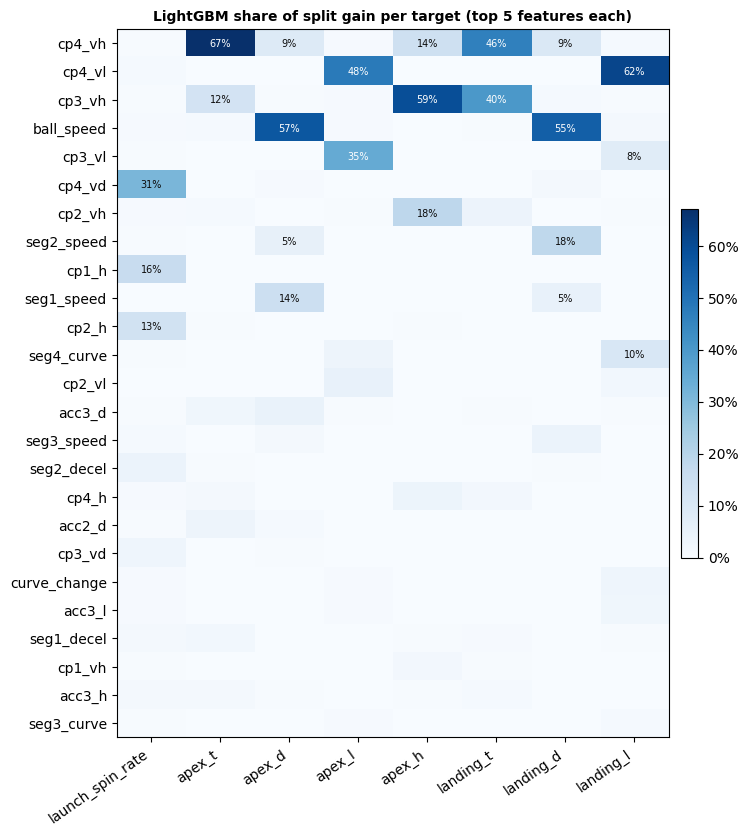

In [10]:
shown = sorted(set().union(*[importance[t].nlargest(5).index for t in SHOT_FRAME_TARGETS]),
               key=lambda f: -importance.loc[f].max())
fig, ax = plt.subplots(figsize=(7.5, 0.32 * len(shown) + 1.2))
data = importance.loc[shown, SHOT_FRAME_TARGETS].to_numpy()
image = ax.imshow(data, cmap="Blues", vmin=0, vmax=data.max(), aspect="auto")
ax.set_xticks(range(len(SHOT_FRAME_TARGETS)), SHOT_FRAME_TARGETS, rotation=35, ha="right")
ax.set_yticks(range(len(shown)), shown)
for i in range(data.shape[0]):
    for j in range(data.shape[1]):
        if data[i, j] >= 0.05:
            ax.text(j, i, f"{data[i, j]:.0%}", ha="center", va="center", fontsize=7,
                    color="white" if data[i, j] > 0.5 * data.max() else "#0b0b0b")
ax.set_title("LightGBM share of split gain per target (top 5 features each)", fontsize=10, fontweight="bold")
ax.grid(False)
fig.colorbar(image, ax=ax, fraction=0.03, pad=0.02, format=lambda v, _: f"{v:.0%}")
fig.savefig(FIG_DIR / "fig08_lgbm_importance.png", dpi=150, bbox_inches="tight", facecolor="#fcfcfb")
plt.show()

### Submission

In [11]:
test_predictions = final.predict(test_s)
write_submission(test_predictions, test, SUBMISSIONS_DIR / "submission_lgbm_baseline_2026-09-16.csv")
print(test_predictions.describe().T[["mean", "min", "max"]].round(2))

VALID   submission_lgbm_baseline_2026-09-16.csv: 559 rows, 10 columns, no problems found
                     mean      min       max
launch_spin_rate  5951.66  1768.26  11238.66
apex_t               2.92     1.30      4.04
apex_x              74.90    10.53    135.28
apex_y              83.31    34.88    129.20
apex_z              24.48     3.94     45.87
landing_t            5.59     2.53      7.71
landing_x          126.84    36.71    211.39
landing_y          109.04    36.14    184.06
landing_z            1.20     0.05      4.12


### Reading the baseline

* LightGBM cuts the composite from about 1.01 (training mean) to about 0.19 under both strategies, with landing position errors of about 6 to 7 m.
* **Spin now carries a disproportionate share.** Its scaled error is about 0.43 to 0.55, against about 0.15 for landing position. With weight 0.10, spin contributes about a quarter of the composite (0.1 x 0.43 / 0.187 = 0.23 within sessions), as anticipated in section 1. Its top feature is speed at the net (`cp4_vd`), a club-type proxy, rather than the lift-related vertical accelerations, so the model is not yet reading spin from the flight itself.
* **Fast band.** Landing error is largest for shots of 70 m/s and above. Within-session CV (which trains on about half the fast shots) is worse there than leave-one-session-out (which trains on nearly all of them), which suggests the fast band is limited by how few fast training shots there are. The final model sees all 37.
* **Hard sessions** in leave-one-session-out are 3 and 8, with 0 close behind. Session 8 is the only session from tee T4, so holding it out means predicting an unseen tee.